In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('parkinsons_disease_data.csv')

## Analysis of Dataset

In [2]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [3]:
display(df.shape)

(2105, 35)

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

None

In [5]:
# Check for null
display(df.isnull().sum().sum())

# Check for duplicates
display(df.duplicated().sum())

np.int64(0)

np.int64(0)

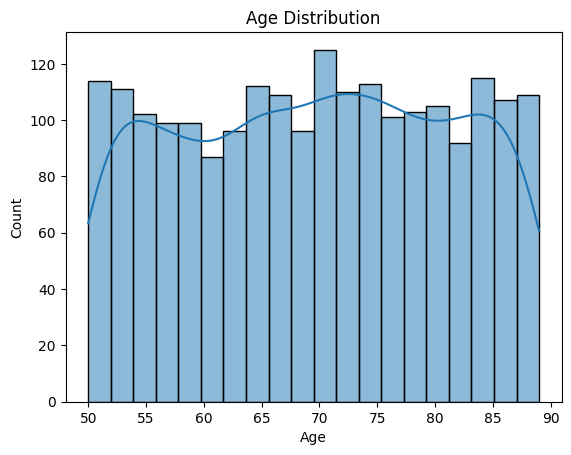

In [6]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

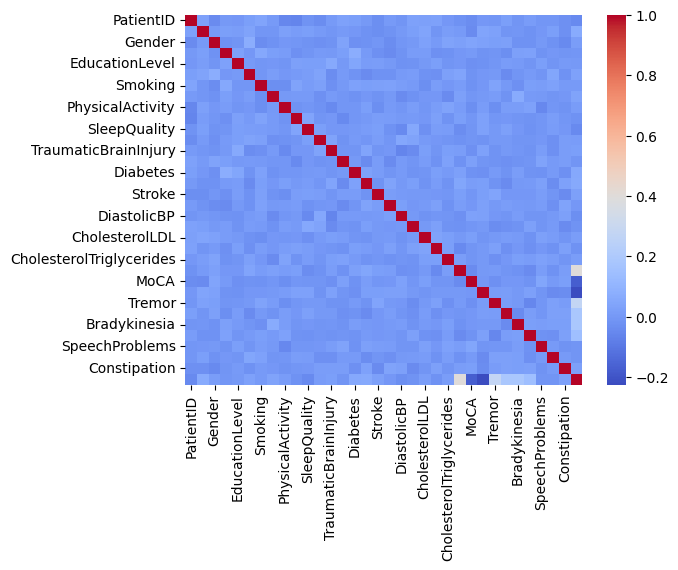

In [7]:
sns.heatmap(df.corr(numeric_only=True), cmap = "coolwarm")
plt.show()

,count
Diagnosis,
1,1304
0,801


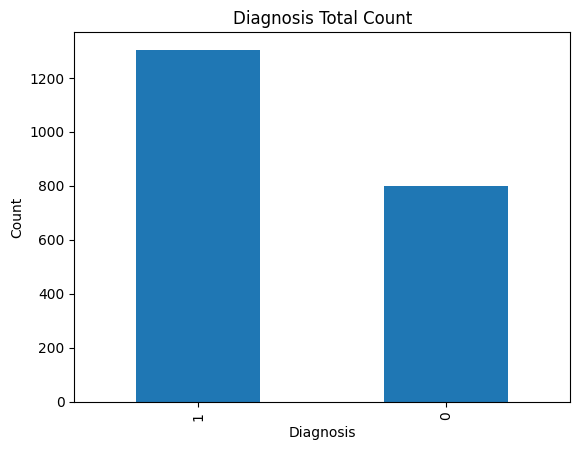

In [8]:
y = df.Diagnosis.value_counts().plot(kind='bar')

plt.ylabel("Count")
plt.title("Diagnosis Total Count")
display(df['Diagnosis'].value_counts().to_frame('count'))

In [9]:
from sklearn.model_selection import train_test_split

# drop patient and doctor columns
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

X = df.drop(columns=['Diagnosis'])
Y = df.Diagnosis

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [10]:
## Preprocessing Dataset

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Resample to balance Dataset
X_train, Y_train = smote.fit_resample(X_train, Y_train)
display(Y_train.value_counts().to_frame('count'))

,count
Diagnosis,
0,1033
1,1033


### Logistic Regression

In [13]:
from models.regression import rg_run_models

rg_models = rg_run_models(X_train, Y_train, X_test, Y_test)
rg_models

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix
0,Logistic Regression,\tClass Weight: Balanced\n\tMax Iter: 5000,SVM,0.809976,0.871595,0.826568,0.848485,"[[117, 33], [47, 224]]"


### RBF Kernel SVM

In [14]:
from models.svm import svm_run_models

svm_models = svm_run_models(X_train, Y_train, X_test, Y_test)
svm_models

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix
0,RBF Kernel,\tRegularization Param: 1\n\tKernel: RBF\n\tGa...,SVM,0.771971,0.830189,0.811808,0.820896,"[[105, 45], [51, 220]]"


### Neural Network Model

In [15]:
from models.neural_net import nn_run_models

nn_models = nn_run_models(X_train, Y_train, X_test, Y_test)
nn_models # Show stats output as table

[0.4315989315509796, 0.786223292350769, 0.8415094614028931, 0.8228782415390015, 0.7832369804382324, 108.0, 42.0, 48.0, 223.0]


,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix
0,"leaky_relu, adam, binary_crossentropy","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.786223,0.841509,0.822878,0.783237,"[[[108.0, 42.0]], [48.0, 223.0]]"
